# `DiscreteControlLoopSimulator` demo: stabilizing a 1D linear-Gaussian system

This notebook demonstrates `dynestyx.control.discrete_controller_simulators.DiscreteControlLoopSimulator`, which implements the online control loop

```
x_0 ~ p(x_0)
y_0 | x_0 ~ p(y_0 | x_0, t_0)
x_hat_{0|0} = FilterUpdate(y_0, t_0)
u_k, s_{k+1} = control_policy(x_hat_{k|k}, s_k)
x_{k+1} | x_k, u_k ~ p(x_{k+1} | x_k, u_k, t_k, t_{k+1})
y_{k+1} | x_{k+1}, u_k ~ p(y_{k+1} | x_{k+1}, u_k, t_{k+1})
x_hat_{k+1|k+1} = FilterUpdate(x_hat_{k|k}, u_k, y_{k+1}, t_k, t_{k+1})
```

at each step, sampling the next state and observation, filtering the observation into an updated belief, and asking the policy for the next control -- all online, unlike `DiscreteTimeSimulator`, which requires the entire control trajectory to be supplied up front.

We use:
1. a simple 1D linear-Gaussian dynamical system (a noisy random walk, `x_{k+1} = A x_k + B u_k + noise`) with the full state directly observed under Gaussian noise,
2. a linear feedback policy `u_k = -K x_hat_k` that drives the state toward 0,
3. a plot comparing the controlled trajectory against an uncontrolled (`K=0`) baseline.

In [1]:
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.handlers import seed

import dynestyx as dsx
from dynestyx.control.discrete_controller_simulators import DiscreteControlLoopSimulator, filter_state_mean
from dynestyx.inference.configs.filter import KFConfig
from dynestyx.models import DynamicalModel
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution

## 1. Define the dynamics

`state_dim = control_dim = observation_dim = 1`. The transition is `x_{k+1} = A x_k + B u_k + noise`, with `A = 1` -- a marginally-unstable random walk when uncontrolled, so the effect of feedback control is visually obvious. The observation model directly observes the full state under additive Gaussian noise (`H = I`, no control dependence).

In [2]:
state_dim = control_dim = obs_dim = 1

dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.array([5.0]), 0.1 * jnp.eye(state_dim)),
    state_evolution=LinearGaussianStateEvolution(
        A=jnp.array([[1.0]]), B=jnp.array([[1.0]]), cov=0.05 * jnp.eye(state_dim)
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim, state_dim), R=0.2 * jnp.eye(obs_dim)
    ),
    control_dim=control_dim,
)

## 2. Define the controller

A simple linear feedback policy `u = -K x_hat`, implemented as an `equinox.Module` (per the control-loop's requirement that the policy be any callable, e.g. a learned neural policy or, as here, a fixed gain). `filter_state_mean` extracts a point estimate from whatever filter-family belief `DiscreteControlLoopSimulator` produces (Kalman-family states expose `.mean` directly; particle-filter states are summarized as a weighted mean instead), so the same policy code works regardless of `filter_config`.

With `A - B*K = 1 - 0.5 = 0.5`, well inside the unit circle, the closed loop should converge to 0.

In [3]:
class LinearPolicy(eqx.Module):
    K: jnp.ndarray

    def __call__(self, x_hat, s, key):
        return -self.K @ filter_state_mean(x_hat), s

## 3. Run the closed loop, with and without control

`DiscreteControlLoopSimulator` is used the same way as any other dynestyx simulator: `with sim: dsx.sample(name, dynamics, predict_times=...)` inside a model function, run under a seeded NumPyro context. We use `predict_times` (not `obs_times`/`ctrl_times`) since this is forward rollout with no conditioning and no pre-supplied controls -- the whole point is that the trajectory doesn't exist yet until the loop generates it. `filter_config=KFConfig(record_filtered_states_mean=True)` makes the filtered state estimate available as an output (it's needed internally either way, for the policy; this only controls whether it's also returned). We run twice: once with the stabilizing gain `K=0.5`, once with `K=0` (no control) as a baseline.

In [4]:
predict_times = jnp.arange(0.0, 30.0)


def run(K: float):
    policy = LinearPolicy(K=jnp.array([[K]]))

    def model():
        with DiscreteControlLoopSimulator(
            control_policy=policy,
            policy_state_init=None,
            filter_config=KFConfig(record_filtered_states_mean=True),
        ):
            return dsx.sample("loop", dynamics, predict_times=predict_times)

    with seed(rng_seed=0):
        return numpyro.handlers.trace(model).get_trace()


trace_controlled = run(K=0.5)
trace_uncontrolled = run(K=0.0)

## 4. Plot the resulting dynamics

Top panel: noisy observations (dots) and the filtered state estimate (line) for both runs -- since the full state is directly observed here, the observations already closely track the true state, and the filtered estimate smooths out the sensor noise. Bottom panel: the control sequence chosen online by the policy for the controlled run.

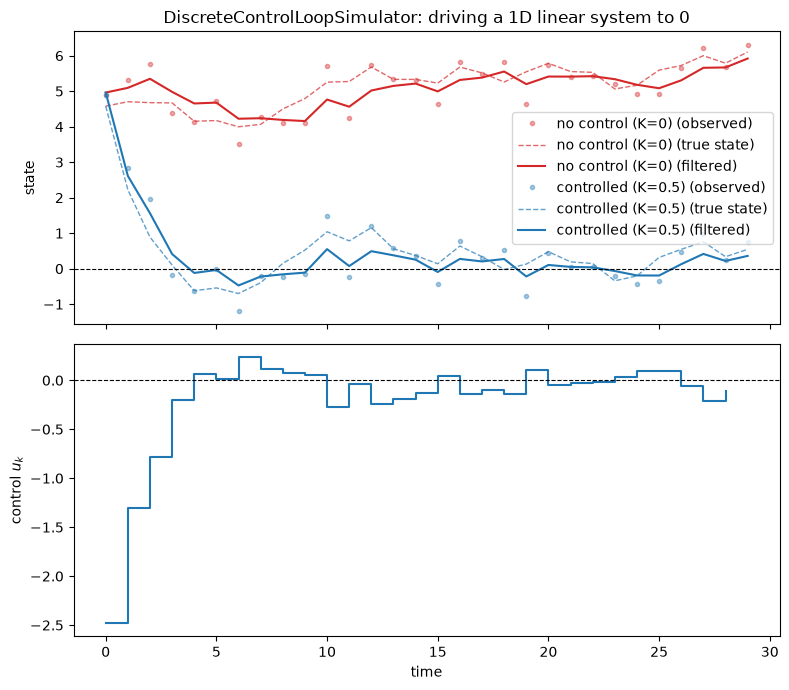

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs = [
    (trace_uncontrolled, "no control (K=0)", "tab:red"),
    (trace_controlled, "controlled (K=0.5)", "tab:blue"),
]
for trace, label, color in runs:
    t = trace["loop_times"]["value"][0]
    true_state = trace["loop_states"]["value"][0, :, 0]
    obs = trace["loop_observations"]["value"][0, :, 0]
    filtered_mean = trace["loop_filtered_states_mean"]["value"][0, :, 0]
    axes[0].plot(t, obs, ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, true_state, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("DiscreteControlLoopSimulator: driving a 1D linear system to 0")

t_u = trace_controlled["loop_times"]["value"][0][:-1]
u = trace_controlled["loop_controls"]["value"][0, :, 0]
axes[1].step(t_u, u, where="post", color="tab:blue")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()

## 5. A genuinely continuous-time system, observed at discrete times

So far the dynamics were already discrete-time. But the control loop's transition $p(x_{k+1} \mid x_k, u_k, t_k, t_{k+1})$ is allowed to be *any* black-box callable -- including a real continuous-time SDE solved between two requested discrete times, with `DiscreteControlLoopSimulator` never seeing anything but the discrete grid.

We define the state evolution as a genuine `ContinuousTimeStateEvolution` ($dx_t = u_t\,dt + \sigma\,dW_t$ -- the same control-driven random walk as before, but now a true SDE instead of a discrete-time transition), and wrap it with `dynestyx.discretizers.Discretizer(discretize=euler_maruyama)`. `Discretizer` is itself a `dsx.sample`-intercepting handler: entered *inside* `DiscreteControlLoopSimulator` (closer to the `dsx.sample` call), it replaces the continuous-time `state_evolution` with its Euler-Maruyama discretization *before* forwarding to the simulator, so from `DiscreteControlLoopSimulator`'s point of view the model is discrete-time all along -- exactly the same composition already used for `Filter` in dynestyx's filtering tutorials.

**How the integration is actually defined:** `euler_maruyama` takes exactly *one* Euler-Maruyama step over the whole gap `dt = t_next - t_now` between two requested times -- no internal sub-stepping. This is deliberate: a filter needs an explicit, differentiable one-step transition *density* between each pair of times, so nothing can be hidden inside smaller substeps the way a pure forward simulator could (dynestyx's `SDESimulator`/`solve_sde` do sub-step, with a fixed tiny `dt0` or full Diffrax adaptive integration, but only for simulation without filtering). So the transition's accuracy here is exactly first-order-Euler-Maruyama over the *whole* requested gap -- fine for the gentle linear system above, but for a genuinely nonlinear drift the gap between `predict_times` needs to be small enough for that one-step approximation to stay reasonable, as in the nonlinear example below.

In [6]:
from dynestyx.discretizers import Discretizer, euler_maruyama
from dynestyx.inference.configs.filter import EKFConfig
from dynestyx.models import ContinuousTimeStateEvolution, FullDiffusion

sigma = 0.2

continuous_dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.array([5.0]), 0.1 * jnp.eye(state_dim)),
    state_evolution=ContinuousTimeStateEvolution(
        drift=lambda x, u, t: u,
        diffusion=FullDiffusion(sigma * jnp.eye(state_dim)),
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim, state_dim), R=0.2 * jnp.eye(obs_dim)
    ),
    control_dim=control_dim,
)
print("continuous_time:", continuous_dynamics.continuous_time)

continuous_time: True


We use `EKFConfig` here rather than `KFConfig`: Euler-Maruyama discretization produces a Gaussian transition each step, but (for a general, possibly nonlinear, drift/diffusion) not necessarily one of the specific `LinearGaussianStateEvolution` form `KFConfig` requires, so `DiscreteControlLoopSimulator` needs the Taylor-linearized Kalman filter instead. `filter_state_mean` and `LinearPolicy` from above are reused unchanged -- the policy code does not need to know whether the belief came from a discrete or a discretized-continuous model.

In [7]:
def run_sde(K: float):
    policy = LinearPolicy(K=jnp.array([[K]]))

    def model():
        with DiscreteControlLoopSimulator(
            control_policy=policy,
            policy_state_init=None,
            filter_config=EKFConfig(record_filtered_states_mean=True),
        ):
            with Discretizer(discretize=euler_maruyama):
                return dsx.sample("loop_sde", continuous_dynamics, predict_times=predict_times)

    with seed(rng_seed=0):
        return numpyro.handlers.trace(model).get_trace()


trace_sde_controlled = run_sde(K=0.5)
trace_sde_uncontrolled = run_sde(K=0.0)

Same reading as the discrete-time plot above: true state (dashed), noisy observation (dots), and filtered estimate (solid) for both runs, plus the control sequence chosen online for the controlled run. The dynamics are now genuinely continuous between observation times -- only the Euler-Maruyama discretization inside `Discretizer` makes them presentable to the discrete-time control loop.

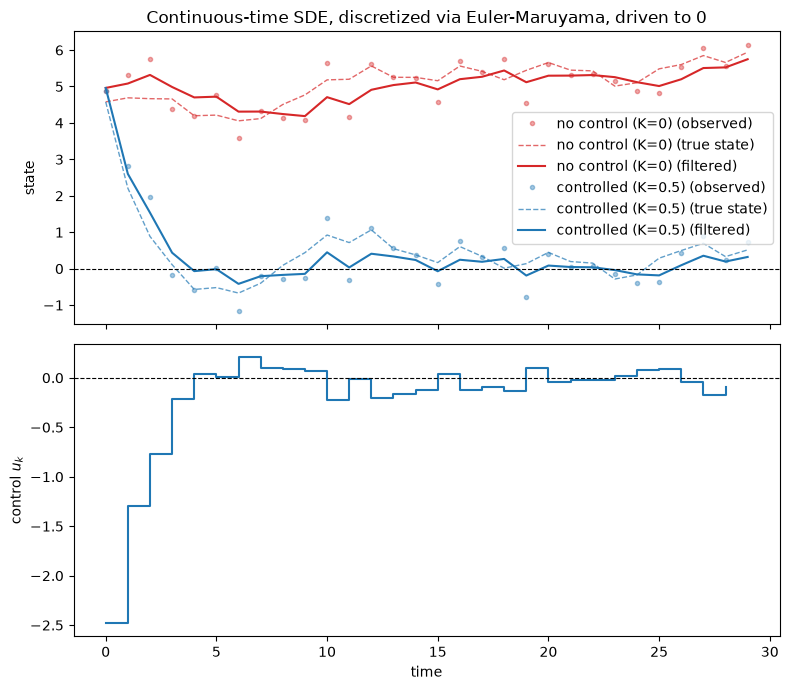

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs = [
    (trace_sde_uncontrolled, "no control (K=0)", "tab:red"),
    (trace_sde_controlled, "controlled (K=0.5)", "tab:blue"),
]
for trace, label, color in runs:
    t = trace["loop_sde_times"]["value"][0]
    true_state = trace["loop_sde_states"]["value"][0, :, 0]
    obs = trace["loop_sde_observations"]["value"][0, :, 0]
    filtered_mean = trace["loop_sde_filtered_states_mean"]["value"][0, :, 0]
    axes[0].plot(t, obs, ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, true_state, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("Continuous-time SDE, discretized via Euler-Maruyama, driven to 0")

t_u = trace_sde_controlled["loop_sde_times"]["value"][0][:-1]
u = trace_sde_controlled["loop_sde_controls"]["value"][0, :, 0]
axes[1].step(t_u, u, where="post", color="tab:blue")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()

## 6. A nonlinear 2D system: unstable without control

The same recipe -- `ContinuousTimeStateEvolution` + `Discretizer` + `DiscreteControlLoopSimulator` -- works unchanged for a genuinely nonlinear, multi-dimensional drift. Here the (uncontrolled) drift is $A x^2$ (elementwise square, then a linear map): since $x^2 \ge 0$ regardless of the sign of $x$, this drift always pushes the state further from the origin -- $x=0$ is an *unstable* equilibrium, and without control the state runs away to infinity in finite time. The same linear feedback policy as before, $u = -K\hat x$, is enough to stabilize it: near the origin the linear term dominates the quadratic one, so control wins locally (for $x$ small enough relative to $K/A$) even though it does nothing to fix the global instability.

Because the drift is now genuinely nonlinear, the one-step Euler-Maruyama approximation described above needs a finer time grid to stay accurate over each step -- so `predict_times` here uses steps of `0.1` rather than `1.0`.

In [9]:
state_dim_2d = control_dim_2d = obs_dim_2d = 2
A = 0.05 * jnp.eye(state_dim_2d)
sigma_2d = 0.1

nonlinear_dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(
        jnp.array([3.0, -2.0]), 0.05 * jnp.eye(state_dim_2d)
    ),
    state_evolution=ContinuousTimeStateEvolution(
        drift=lambda x, u, t: A @ (x**2) + u,
        diffusion=FullDiffusion(sigma_2d * jnp.eye(state_dim_2d)),
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim_2d, state_dim_2d), R=0.05 * jnp.eye(obs_dim_2d)
    ),
    control_dim=control_dim_2d,
)

The controller is the same `LinearPolicy` as before, only with a $2\times2$ gain `K = k \cdot I`; `k=0` reproduces the uncontrolled (unstable) system.

In [10]:
predict_times_2d = jnp.arange(0.0, 6.0, 0.1)


def run_2d(k: float):
    policy = LinearPolicy(K=k * jnp.eye(control_dim_2d))

    def model():
        with DiscreteControlLoopSimulator(
            control_policy=policy,
            policy_state_init=None,
            filter_config=EKFConfig(record_filtered_states_mean=True),
        ):
            with Discretizer(discretize=euler_maruyama):
                return dsx.sample(
                    "loop_2d", nonlinear_dynamics, predict_times=predict_times_2d
                )

    with seed(rng_seed=0):
        return numpyro.handlers.trace(model).get_trace()


trace_2d_controlled = run_2d(k=1.0)
trace_2d_uncontrolled = run_2d(k=0.0)

Top two panels: each state dimension, true (dashed) vs. filtered (solid), for both runs. Bottom panel: the two control channels for the controlled run. Without control both dimensions run away (note $x_1$'s accelerating, textbook finite-time-blowup shape); with control both converge to 0 and the control effort tapers off as they arrive.

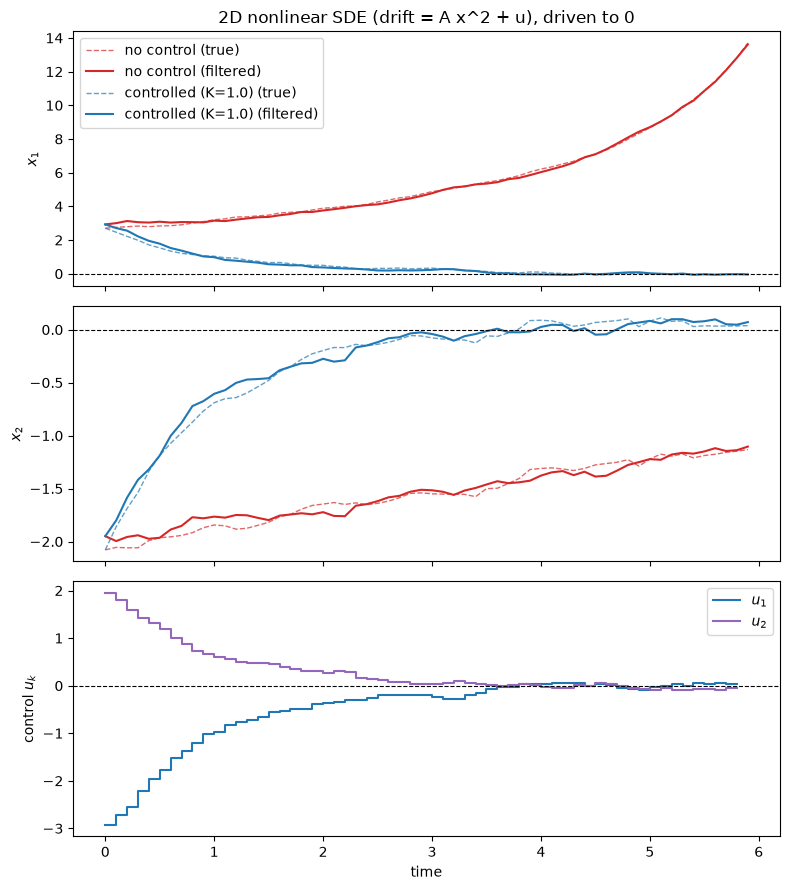

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

runs_2d = [
    (trace_2d_uncontrolled, "no control", "tab:red"),
    (trace_2d_controlled, "controlled (K=1.0)", "tab:blue"),
]
for trace, label, color in runs_2d:
    t = trace["loop_2d_times"]["value"][0]
    true_state = trace["loop_2d_states"]["value"][0]
    filtered_mean = trace["loop_2d_filtered_states_mean"]["value"][0]
    axes[0].plot(t, true_state[:, 0], "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true)")
    axes[0].plot(t, filtered_mean[:, 0], "-", color=color, label=f"{label} (filtered)")
    axes[1].plot(t, true_state[:, 1], "--", color=color, alpha=0.7, linewidth=1)
    axes[1].plot(t, filtered_mean[:, 1], "-", color=color)

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("$x_1$")
axes[0].legend()
axes[0].set_title("2D nonlinear SDE (drift = A x^2 + u), driven to 0")

axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("$x_2$")

t_u = trace_2d_controlled["loop_2d_times"]["value"][0][:-1]
u = trace_2d_controlled["loop_2d_controls"]["value"][0]
axes[2].step(t_u, u[:, 0], where="post", color="tab:blue", label="$u_1$")
axes[2].step(t_u, u[:, 1], where="post", color="tab:purple", label="$u_2$")
axes[2].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_ylabel("control $u_k$")
axes[2].set_xlabel("time")
axes[2].legend()

plt.tight_layout()
plt.show()